In [1]:
!pip install tensorflow
!pip install seaborn

!pip install scikit-learn
!pip install matplotlib
!pip install opencv-python
!pip install numpy
!pip install mtcnn



  Using cached protobuf-7.35.1-cp310-abi3-win_amd64.whl.metadata (595 bytes)
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB 217.9 kB/s eta 0:00:08
    --------------------------------------- 0.0/1.7 MB 388.9 kB/s eta 0:00:05
   -- ------------------------------------- 0.1/1.7 MB 798.9 kB/s eta 0:00:02
   ----- ---------------------------------- 0.2/1.7 MB 1.3 MB/s eta 0:00:02
   ------- -------------------------------- 0.3/1.7 MB 1.5 MB/s eta 0:00:01
   ---------- ----------------------------- 0.4/1.7 MB 1.6 MB/s eta 0:00:01
   ------------- -------------------------- 0.6/1.7 MB 1.9 MB/s eta 0:00:01
   --------------- ------------------------ 0.7/1.7 MB 1.9 MB/s eta 0:00:01
   -------------------- ------------------- 0.8/1.7 MB 2.1 MB/s eta 0:00:01
   -----------------------


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

ImportError: DLL load failed while importing _pywrap_tf2: The specified module could not be found.

In [ ]:
IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    "downloads\helmet-image",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "downloads\helmet-image",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 24029 files belonging to 3 classes.
Using 19224 files for training.
Found 24029 files belonging to 3 classes.
Using 4805 files for validation.


In [ ]:
train_ds.class_names

['annotations', 'fruits-360_100x100', 'images']

In [ ]:
import os
import xml.etree.ElementTree as ET
import cv2
import numpy as np

# Step 1: Define mapping (class name → numeric ID)
label_map = {"Without Helmet": 0, "With Helmet": 1}

xml_folder = r"C:\Users\LOQ\Downloads\helmet-image\annotations"   # <-- change to your actual folder
img_folder = r"C:\Users\LOQ\Downloads\helmet-image\images"       # <-- change to your actual folder



images = []
labels = []
val=[]
IMG_SIZE = (224,224)

for xml_file in os.listdir(xml_folder):

    if not xml_file.endswith(".xml"):
        continue

    tree = ET.parse(os.path.join(xml_folder, xml_file))
    root = tree.getroot()

    filename = root.find("filename").text

    img_path = os.path.join(img_folder, filename)

    img = cv2.imread(img_path)

    if img is None:
        continue

    for obj in root.findall("object"):

        class_name = obj.find("name").text.strip()

        if class_name not in label_map:
            continue

        bndbox = obj.find("bndbox")

        xmin = int(bndbox.find("xmin").text)
        ymin = int(bndbox.find("ymin").text)
        xmax = int(bndbox.find("xmax").text)
        ymax = int(bndbox.find("ymax").text)
        val.append([ymin,ymax, xmin,xmax])
        crop = img[ymin:ymax, xmin:xmax]

        if crop.size == 0:
            continue

        crop = cv2.resize(crop, IMG_SIZE)

        crop = crop / 255.0

        images.append(crop)

        labels.append(label_map[class_name])
        

Images shape: (1434, 224, 224, 3)
Labels shape: (1434,)


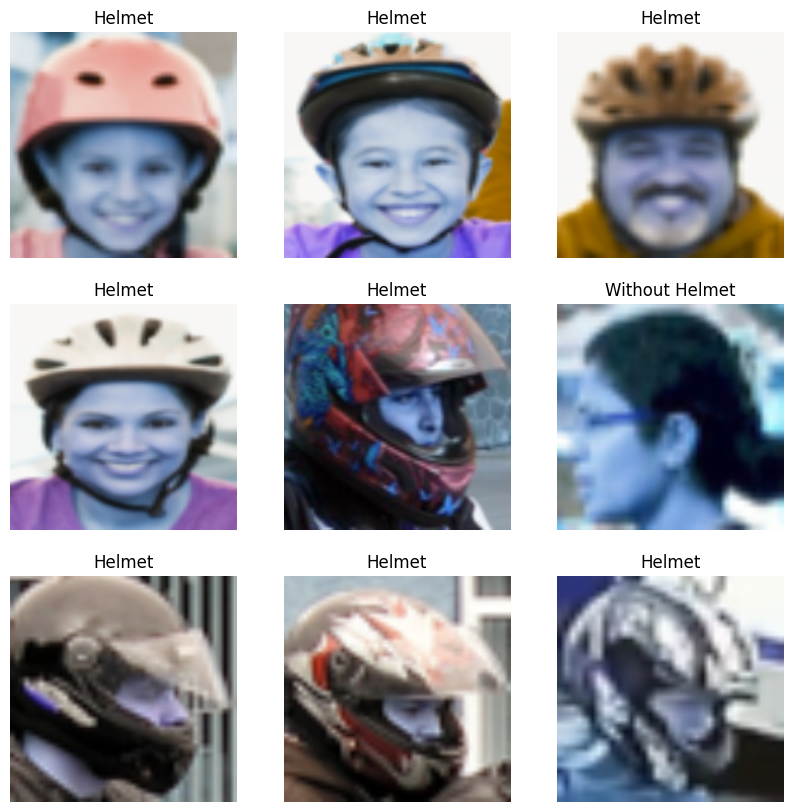

In [ ]:
import matplotlib.pyplot as plt

train_images = np.array(images)
train_labels = np.array(labels)
val_box=np.array(val)
print("Images shape:", train_images.shape)
print("Labels shape:", train_labels.shape)
plt.figure(figsize=(10,10))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(images[i])

    plt.title(
        "Helmet"
        if labels[i] == 1
        else "Without Helmet"
    )

    plt.axis("off")

plt.show()


In [ ]:
# import cv2
# import os

# # Create output folder
# output_dir = r"c:/Users/LOQ/Downloads/helmet-image/train_images"
# os.makedirs(output_dir, exist_ok=True)

# # Loop through and save each cropped image
# for i, img_array in enumerate(train_images):
#     save_path = os.path.join(output_dir, f"train_{i}.jpg")
#     # If normalized (0–1), convert back to 0–255
#     if img_array.max() <= 1.0:
#         img_array = (img_array * 255).astype("uint8")
#     cv2.imwrite(save_path, img_array)

# print("Saved", len(train_images), "cropped training images.")
# val_label_dir = r"C:/Users/LOQ/Downloads/helmet-image/labels/val"
# os.makedirs(val_label_dir, exist_ok=True)

# # Save each coordinate set into a separate .txt file
# for i, box in enumerate(val_box):
#     save_path = os.path.join(val_label_dir, f"val_{i}.txt")
#     with open(save_path, "w") as f:
#         f.write(" ".join(map(str, box)))

Saved 1434 cropped training images.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D, Dense, Activation, Dropout,Flatten
from sklearn.utils import class_weight
import numpy as np

class_weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
model = Sequential()
# Convolutional layers for feature extraction
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
model.add(MaxPooling2D(pool_size=(2,2)))
print(model.output_shape)

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
print(model.output_shape)
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
# Hidden layer
model.add(Dense(64, input_shape=(224,224,3)))
model.add(Activation('relu'))
model.add(Dropout(0.5))
# Output layer

model.add(Dense(1))
model.add(Activation('sigmoid'))
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


from sklearn.model_selection import train_test_split

# Split into train and test sets (80% train, 20% test)
train_images, test_images, train_labels, test_labels = train_test_split(
    train_images, train_labels, test_size=0.2, random_state=42
)
print("Train images:", train_images.shape)
print("Test images:", test_images.shape)
print("Train labels:", train_labels.shape)
print("Test labels:", test_labels.shape)
test_loss, test_acc = model.evaluate(test_images, test_labels)


c:\Users\LOQ\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\LOQ\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


(None, 111, 111, 32)
(None, 54, 54, 64)
Train images: (153, 224, 224, 3)
Test images: (39, 224, 224, 3)
Train labels: (153,)
Test labels: (39,)
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - accuracy: 0.6667 - loss: 0.6697


In [ ]:
history = model.fit(
    train_images, train_labels,
    validation_split=0.2,
    epochs=10,
    batch_size=32, class_weight=dict(enumerate(class_weights))
)

Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 559ms/step - accuracy: 0.6066 - loss: 0.8354 - val_accuracy: 0.7419 - val_loss: 0.5700
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 563ms/step - accuracy: 0.7131 - loss: 0.6345 - val_accuracy: 0.6774 - val_loss: 0.5636
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 536ms/step - accuracy: 0.7951 - loss: 0.5488 - val_accuracy: 0.6774 - val_loss: 0.6939
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 533ms/step - accuracy: 0.8361 - loss: 0.4793 - val_accuracy: 0.7097 - val_loss: 0.6178
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 528ms/step - accuracy: 0.8443 - loss: 0.4533 - val_accuracy: 0.6774 - val_loss: 0.5786
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 516ms/step - accuracy: 0.6721 - loss: 0.5069 - val_accuracy: 0.7742 - val_loss: 0.4726
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 511ms/step - accuracy: 0.8525 - loss: 0.4372 - val_accuracy: 0.8387 - val_loss: 0.4831
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 521ms/step - accuracy: 0.8033 - loss: 0.4497 - val_accuracy: 0.6774 - val_loss:

In [ ]:

test_loss, test_acc = model.evaluate(test_images, test_labels)
print("Test accuracy:", test_acc)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.6667 - loss: 0.5711
Test accuracy: 0.6666666865348816


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
Predicted probability: 0.9998729
Predicted class: with_helmet


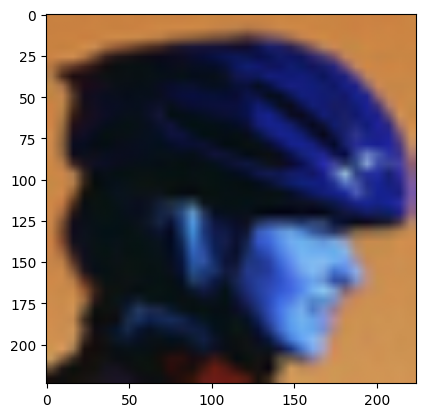

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# Pick one image from your dataset
plt.imshow(train_images[9])  # reshape for batch dimension
sample_img = train_images[9].reshape(1,224,224,3)
prediction = model.predict(sample_img)

print("Predicted probability:", prediction[0][0])
print("Predicted class:", "with_helmet" if prediction[0][0] > 0.3 else "without_helmet")


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


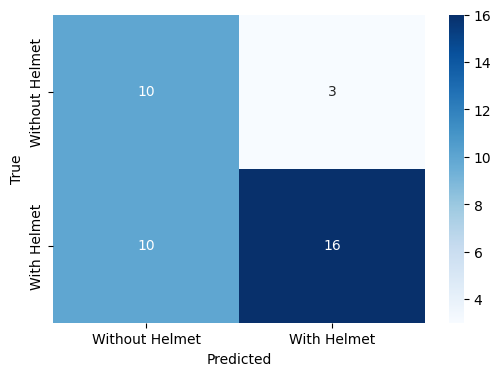

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predict on test set
y_pred = model.predict(test_images)

y_pred_classes = (y_pred > 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(test_labels, y_pred_classes)

# Plot
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Without Helmet','With Helmet'],
            yticklabels=['Without Helmet','With Helmet'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(test_labels, y_pred_classes,
      target_names=['Without Helmet','With Helmet']))




                precision    recall  f1-score   support

Without Helmet       0.50      0.77      0.61        13
   With Helmet       0.84      0.62      0.71        26

      accuracy                           0.67        39
     macro avg       0.67      0.69      0.66        39
  weighted avg       0.73      0.67      0.68        39



In [ ]:
from sklearn.metrics import accuracy_score

acc=accuracy_score(test_labels,y_pred_classes)
acc

0.6666666666666666

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.8432 - loss: 0.4746
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - accuracy: 0.9156 - loss: 0.2501


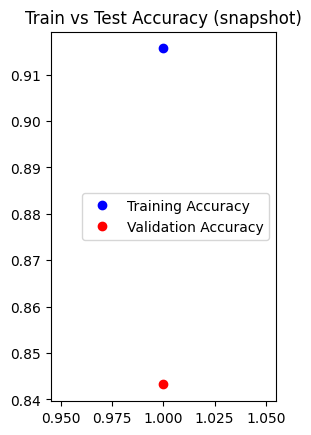

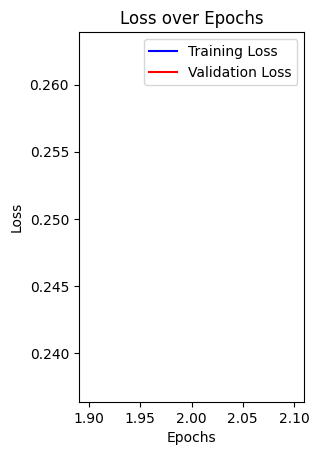

In [ ]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
train_loss, train_acc = model.evaluate(train_images, train_labels)
plt.subplot(1,2,1)

# print(train_loss)
    
plt.plot(1, train_acc, 'bo', label='Training Accuracy')   # blue dot
plt.plot(1, test_acc, 'ro', label='Validation Accuracy')  # red dot
plt.legend()
plt.title("Train vs Test Accuracy (snapshot)")
plt.show()
plt.subplot(1,2,2)
plt.plot(2, train_loss, 'b-', label='Training Loss')
plt.plot(2, train_loss, 'r-', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend()



4


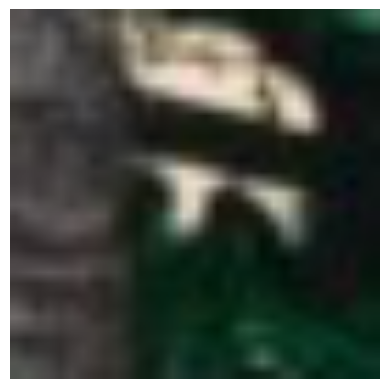

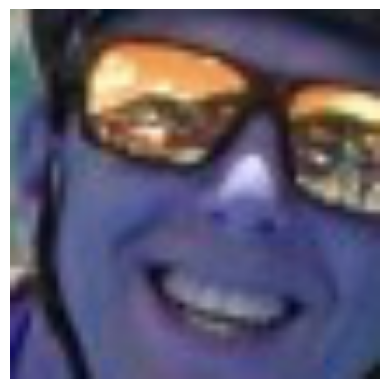

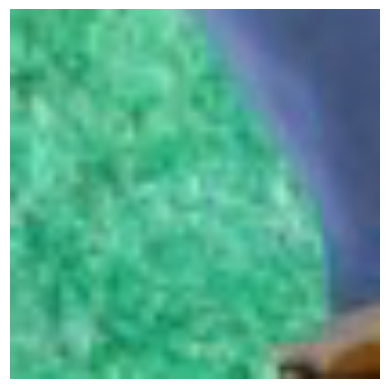

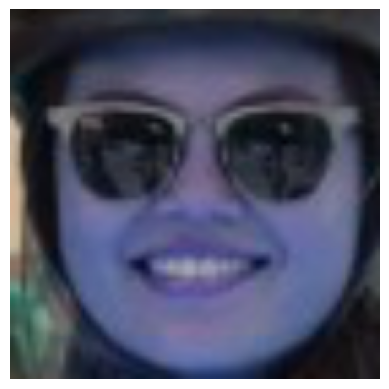

In [ ]:

import cv2
import matplotlib.pyplot as plt

import cv2
import cv2

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
img = cv2.imread(r'c:\Users\LOQ\Downloads\helmet-image\images\BikesHelmets67.png')
# img_demo = cv2.imread(r"c:\Users\LOQ\OneDrive\Desktop\iwt\Screenshot 2026-06-03 004151.png")
# img_demo=cv2.resize(img_demo, (224,224)) 
# img_d = img_demo.astype('float32') / 255.0
# img_d= cv2.cvtColor(img_d,cv2.COLOR_BGR2RGB)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
faces = face_cascade.detectMultiScale(gray, 1.05, 3, minSize=(30, 30) )
a=len(faces)
print(a)
for (x, y, w, h) in faces:
    roi = img[y:y+h, x:x+w]        # crop the face region
    roi_resized = cv2.resize(roi, (224,224))   # resize for CNN
    roi_norm = roi_resized.astype('float32') / 255.0
    roi_norm= cv2.cvtColor(roi_norm,cv2.COLOR_BGR2RGB)
# Load image
# img = cv2.imread(r'c:\Users\LOQ\Downloads\helmet-image\images\BikesHelmets707.png')   # BGR format

# img = cv2.imread(r'c:\Users\LOQ\Downloads\helmet-image\images\BikesHelmets723.png')   # BGR format
# img = cv2.imread(r'c:\Users\LOQ\Downloads\helmet-image\images\BikesHelmets743.png') 

    plt.imshow(cv2.cvtColor(roi_norm, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()



In [ ]:
y=model.predict(roi_norm.reshape(1,224,224,3))
print(y)
a=(y>0.5).astype(int)

if(a[0][0]==1):
    print("with helmet")
else:
    print("without helmet")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
[[0.5317717]]
with helmet
